# IPL 2022 Project

# Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

# Importing Dataset

In [2]:
ipl=pd.read_csv("IPL 2022.csv")

In [3]:
ipl

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


# Basic information

In [4]:
ipl.info

<bound method DataFrame.info of     match_id           date                                         venue  \
0          1  March 26,2022                      Wankhede Stadium, Mumbai   
1          2  March 27,2022                     Brabourne Stadium, Mumbai   
2          3  March 27,2022            Dr DY Patil Sports Academy, Mumbai   
3          4  March 28,2022                      Wankhede Stadium, Mumbai   
4          5  March 29,2022  Maharashtra Cricket Association Stadium,Pune   
..       ...            ...                                           ...   
69        70    May 22,2022                      Wankhede Stadium, Mumbai   
70        71    May 24,2022                         Eden Gardens, Kolkata   
71        72    May 25,2022                         Eden Gardens, Kolkata   
72        73    May 27,2022              Narendra Modi Stadium, Ahmedabad   
73        74    May 29,2022              Narendra Modi Stadium, Ahmedabad   

        team1      team2    stage toss_winn

In [5]:
print(f"your rows are {ipl.shape[0]} and columns are {ipl.shape[1]}")

your rows are 74 and columns are 20


# Lets check null values in columns

In [6]:
ipl.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# Basic Quesions

# 1. which team won most matches

Gujarat 12


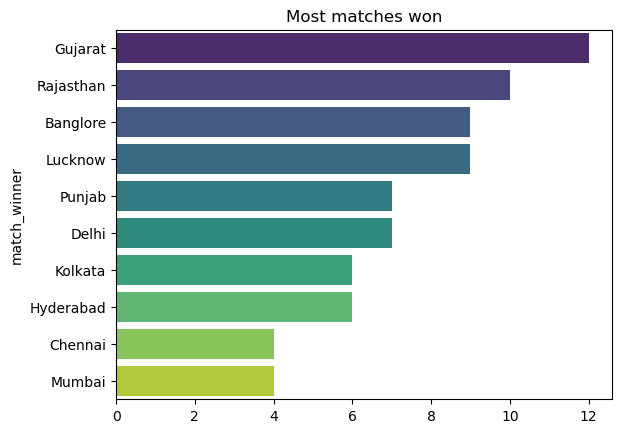

In [7]:
s1=ipl['match_winner'].value_counts()
print(s1.idxmax(),s1.max())
sb.barplot(y=s1.index,x=s1.values,palette="viridis")
plt.title("Most matches won")
plt.show()

# 2. Toss decision Trends

toss_decision
Field    59
Bat      15
Name: count, dtype: int64


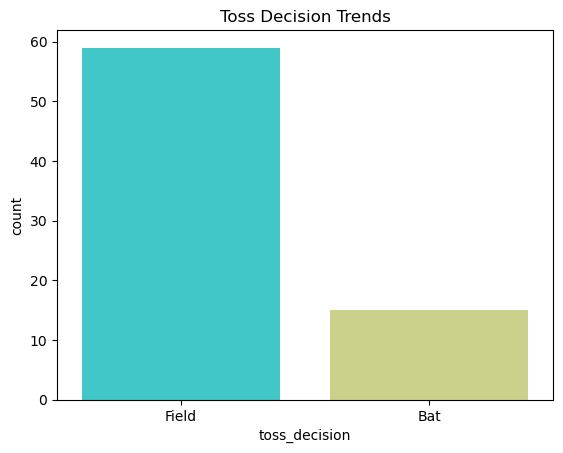

In [8]:
print(ipl['toss_decision'].value_counts())
sb.countplot(x=ipl['toss_decision'],palette='rainbow',hue_order=['Field','Bat'])
plt.title("Toss Decision Trends")
plt.show()

# 3. Toss winner vs Match winner

In [9]:
c1=ipl[ipl['toss_winner']==ipl['match_winner']]['match_id'].count()
persentage=(c1*100)/ipl['match_id'].count()
print(f"total match win persentage after winning toss is {persentage.round(2)}")

total match win persentage after winning toss is 48.65


# 4. How do team wins (by Runs or Wickets)

won_by
Wickets    37
Runs       37
Name: count, dtype: int64


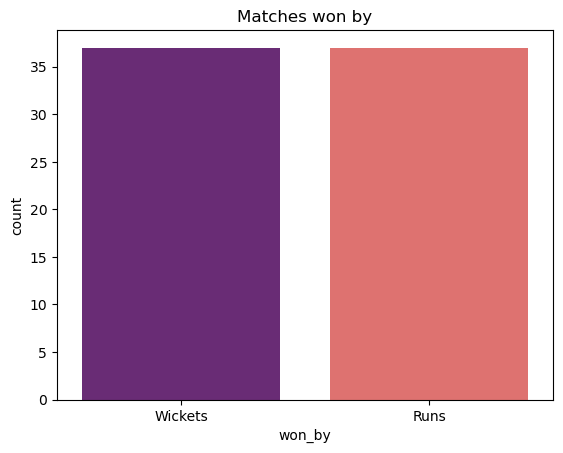

In [10]:
s2=ipl['won_by'].value_counts()
print(s2)
sb.countplot(x='won_by',data=ipl,palette='magma')
plt.title('Matches won by')
plt.show()

# Key Player Performence

# 1. Most "Player of the Match"

Most player of the match winner in IPL 2022 is Kuldeep Yadav with 4 player of the match awards


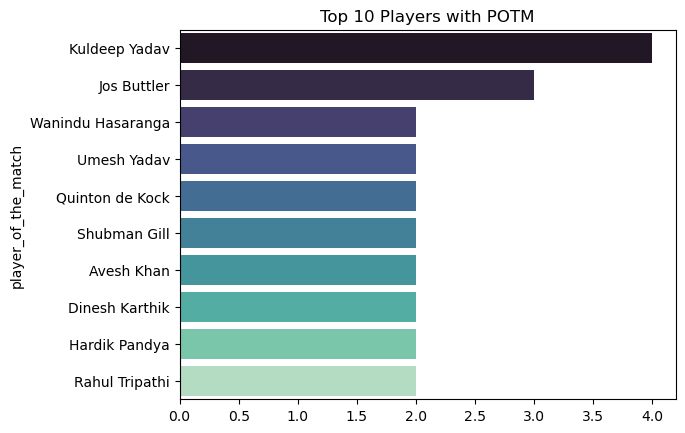

In [11]:
pm=ipl['player_of_the_match'].value_counts().head(10)  #top 10
print(f"Most player of the match winner in IPL 2022 is {pm.idxmax()} with {pm.max()} player of the match awards")
sb.barplot(y=pm.index,x=pm.values,palette='mako')
plt.title("Top 10 Players with POTM")
plt.show()

# 2. Top Ten highscorers in Match

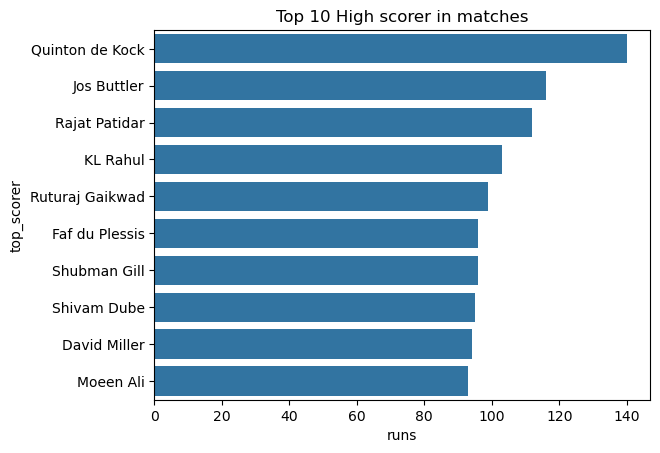

In [12]:
s=ipl.groupby('top_scorer')['highscore'].max().sort_values(ascending=False).head(10)
sb.barplot(x=s.values,y=s.index)
plt.title("Top 10 High scorer in matches")
plt.xlabel("runs")
plt.show()

# 3. Ten Most Wicket taker in a match

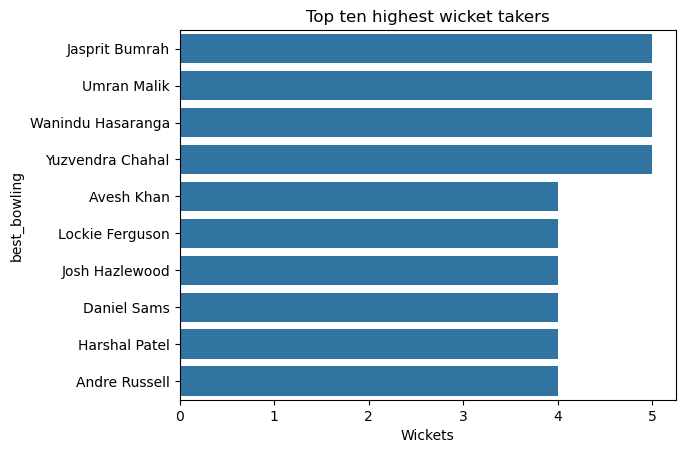

In [13]:
ipl['highest_wicket']=ipl['best_bowling_figure'].apply(lambda x :x.split('--')[0])
ipl['highest_wicket']=ipl['highest_wicket'].astype(int)

g1=ipl.groupby('best_bowling')['highest_wicket'].max().sort_values(ascending=False).head(10)
sb.barplot(x=g1.values,y=g1.index)
plt.title("Top ten highest wicket takers")
plt.xlabel("Wickets")
plt.show()

# Venue Analysis

# 1. Most Matches played by a venue

Most matches are played at Wankhede Stadium, Mumbai are  21


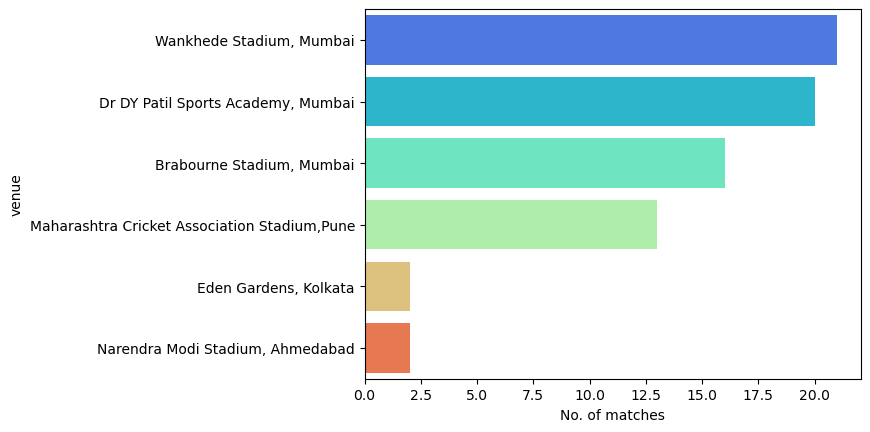

In [14]:
g2=ipl.groupby('venue')['match_id'].count().sort_values(ascending=False)
print(f"Most matches are played at {g2.index.max()} are  {g2.values.max()}")
sb.barplot(x=g2.values,y=g2.index,palette='rainbow')
plt.xlabel("No. of matches")
plt.show()

# Custom Questions and insights

# 1. Who won match by highest margin

In [15]:
ipl[ipl['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]


,match_winner,margin
54,Chennai,91


# 2. Which player had the highest individual score?

In [16]:
#method 2
s=ipl.groupby('top_scorer')['highscore'].max().sort_values(ascending=False).head(10)
print(f"Highest individual score is {s.max()} by {s.idxmax()}")

Highest individual score is 140 by Quinton de Kock


In [17]:
#method 2
ipl[ipl['highscore']==ipl['highscore'].max()][['match_id','player_of_the_match','highscore']]

,match_id,player_of_the_match,highscore
65,66,Quinton de Kock,140


# 3. Which bowler had the Best Bowling figures?

In [18]:
ipl[ipl['highest_wicket']==ipl['highest_wicket'].max()][['match_id','best_bowling','highest_wicket']]

,match_id,best_bowling,highest_wicket
29,30,Yuzvendra Chahal,5
39,40,Umran Malik,5
53,54,Wanindu Hasaranga,5
55,56,Jasprit Bumrah,5
